### L16 Notes. Dimension Reduction

### Set up imports

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

### Load data

In [34]:
rhodo_df = pd.read_csv('rhodo_data.csv')

rhodo_df

,sample,2-aminoadipic acid,2'-Deoxycytidine 5'-monophosphoric acid,3-phosphoglycerate,4-aminobutyric acid (GABA),Adenine,Arachidic acid,Beta-alanine,Carbonate ion,Citric acid,...,Maltotriose,Melibiose,O-phospho-L-serine,PhlorobenzoPHEnone,Phytanic acid,Porphine,Shikimate-3-phosphate,Turanose,Unknown - Carbohydrate 001,Unknown - Carbohydrate 002
0,SG_1,3.615204e+05,158448.34340,322605.073300,6.771950e+05,710902.5555,21587.08363,1742924.769,2187317.706,73643.82800,...,197109.09810,154515.48230,912327.96570,54886.78433,53255.60385,1.567848e+06,79592.74450,41592.877790,106902.772700,178790.735700
1,SG_2,2.273096e+05,213583.36610,312837.429400,5.758221e+05,510742.4749,30589.63167,1362157.065,2078919.836,85094.11759,...,132211.94520,178537.38880,546466.68580,13966.87377,54527.47672,9.428716e+05,101591.31180,125701.005500,92505.279630,61108.725740
2,SG_3,3.980749e+05,211939.49670,296180.631000,8.199962e+05,618736.8906,43765.31576,1604466.573,2008970.447,110175.16010,...,130384.73450,92173.05823,656821.37520,26902.58320,56933.25213,1.269754e+06,74901.17809,93064.523230,130229.341300,70565.038360
3,GLC_1,3.071484e+05,67093.51243,688993.874800,7.896841e+04,454156.4570,49204.36451,1682083.443,1673533.919,260517.75720,...,91569.05481,73835.03454,144954.93120,24396.52207,80936.68966,1.503872e+06,76117.45934,73153.623310,33556.786250,93378.791060
4,GLC_2,5.243990e+05,92799.06573,846794.369400,2.724752e+05,429740.5506,54159.88575,1807988.441,1892648.079,289564.42380,...,88155.78074,89790.55155,180957.49260,21501.92932,57578.22687,1.347206e+06,92921.82743,102860.222400,17502.190770,94526.402150
5,GLC_3,2.750793e+05,91128.01027,541526.933000,8.573456e+04,392350.9899,55007.71791,1366642.368,2027582.822,228498.81640,...,41202.29249,36081.98794,108310.73210,18244.73367,41068.82030,1.075354e+06,69859.45158,54034.737470,38779.884860,22869.021230
6,PHE_1,2.040576e+06,62117.76873,29381.113820,9.267515e+05,488827.4470,17656.03153,1913257.209,1640787.714,139057.66300,...,38837.83117,98097.36541,125287.66010,27897.99963,68897.32167,1.897504e+06,46513.83213,49661.397290,35115.049840,42814.000000
7,PHE_2,1.720015e+06,39870.09676,16093.138450,5.679310e+05,379245.5165,34278.42471,1657865.525,1595261.253,0.00000,...,35347.05463,72820.82375,113649.50930,21830.58759,59804.93927,1.686061e+06,44079.80613,27107.000000,35295.414120,39200.659430
8,PHE_3,1.587765e+06,46410.23775,9265.648055,5.389106e+05,351121.7984,46926.60926,1437947.627,1592373.937,79803.27844,...,29388.86864,52348.61379,97472.97772,15882.12886,98038.05559,1.505561e+06,30046.62089,9039.363119,9387.535849,1790.613584
9,GLC/PHE_1,5.320456e+06,75728.42913,84282.478150,2.699785e+05,534609.9798,54335.89125,2219697.781,1831849.039,235961.82360,...,118438.37920,119288.08970,334427.23700,45598.67413,48014.39780,1.664952e+06,68660.57585,64619.099360,62026.678030,87521.044140


### Process the data

In [35]:
# separate the labels
labels = rhodo_df['sample']

#drop the sample column
rhodo_df = rhodo_df.drop('sample', axis=1)

In [36]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(rhodo_df)

scaled_data

array([[-0.87621074, -0.20197304,  0.20664732, ..., -0.67650501,
        -0.08231654,  1.68116006],
       [-0.89321871,  0.18515493,  0.16316694, ...,  0.47405885,
        -0.20615757, -0.50091226],
       [-0.87157834,  0.17361258,  0.0890197 , ...,  0.02760548,
         0.11832856, -0.32557231],
       ...,
       [ 0.99942749,  1.60318897, -0.01972194, ...,  0.33462658,
         0.96498144, -0.02406692],
       [ 1.4670534 ,  1.5972777 ,  0.02721908, ..., -1.2454781 ,
         1.79887184,  0.98375957],
       [ 1.23381305,  2.33134609,  0.07721695, ...,  3.22289958,
         2.04451817, -0.15678691]], shape=(18, 86))

### Run PCA

In [37]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])    

#add labels to dataframe
pca_df['sample'] = labels

pca_df

,PC1,PC2,sample
0,1.626407,6.123725,SG_1
1,0.416424,5.379444,SG_2
2,0.603286,6.673287,SG_3
3,-7.718434,2.521469,GLC_1
4,-7.744082,3.409572,GLC_2
5,-7.179410,0.775556,GLC_3
6,-3.730115,-5.164253,PHE_1
7,-3.972550,-4.976868,PHE_2
8,-4.361938,-5.511135,PHE_3
9,-2.597531,-0.992549,GLC/PHE_1


### Analyze the PCA results

In [38]:
variances = pca.explained_variance_ratio_

pc1_var, pc2_var = variances

pc1_var, pc2_var

(np.float64(0.3347293240367785), np.float64(0.17379841284557881))

### Plot the PCA data

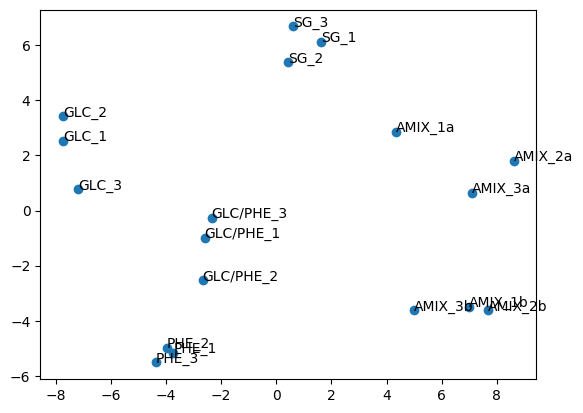

In [39]:
plt.scatter(pca_df['PC1'], pca_df['PC2'])

# add annotations
for index, label in enumerate(pca_df['sample']):
    plt.annotate(label, (pca_df['PC1'][index], pca_df['PC2'][index]))

### Set up data for LDA

In [45]:
classes = [label.split('_')[0] for label in labels]

classes

['SG',
 'SG',
 'SG',
 'GLC',
 'GLC',
 'GLC',
 'PHE',
 'PHE',
 'PHE',
 'GLC/PHE',
 'GLC/PHE',
 'GLC/PHE',
 'AMIX',
 'AMIX',
 'AMIX',
 'AMIX',
 'AMIX',
 'AMIX']

### Run the LDA

In [46]:
lda = LDA(n_components=2)

# run it
lda_data = lda.fit_transform(scaled_data, classes)

lda_df = pd.DataFrame(data=lda_data, columns=['LD1', 'LD2'])

# add labels to dataframe
lda_df['sample'] = labels

### Plot the LDA results

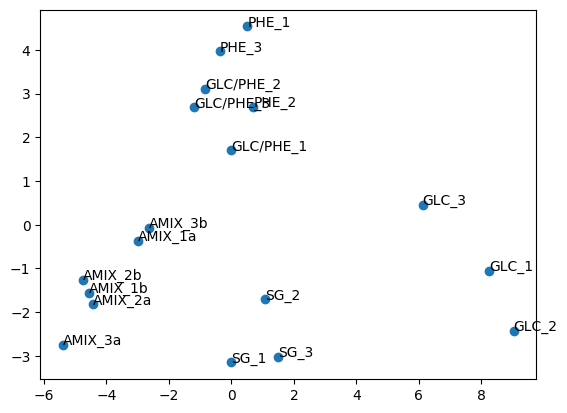

In [48]:
plt.scatter(lda_df['LD1'], lda_df['LD2'])

#add annotations
for label, x_val, y_val in zip(labels, lda_df['LD1'], lda_df['LD2']):
    plt.annotate(label, (x_val, y_val))

### Run t-SNE

In [55]:
tsne = TSNE(n_components=2, perplexity=2, random_state=42)

#run it
tsne_data = tsne.fit_transform(scaled_data) 

#convert to dataframe
tsne_df = pd.DataFrame(data=tsne_data, columns=['tSNE1', 'tSNE2'])  

tsne_df['sample'] = labels

tsne_df

,tSNE1,tSNE2,sample
0,-70.989777,-194.604675,SG_1
1,-80.931511,-182.476212,SG_2
2,-76.070175,-188.846390,SG_3
3,-41.818260,156.086777,GLC_1
4,-36.363205,151.110626,GLC_2
5,-34.523911,162.160736,GLC_3
6,65.418373,-96.630196,PHE_1
7,72.228317,-103.619247,PHE_2
8,77.178581,-108.755249,PHE_3
9,88.780380,-71.470016,GLC/PHE_1


### Plot the results

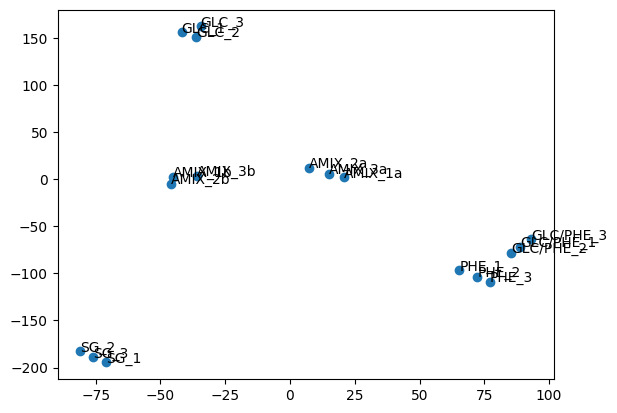

In [57]:
plt.scatter(tsne_df['tSNE1'], tsne_df['tSNE2'])

for index, row in tsne_df.iterrows():
    plt.annotate(row['sample'], (row['tSNE1'], row['tSNE2']))

### Activity: Compare t-SNE with different perplexity values

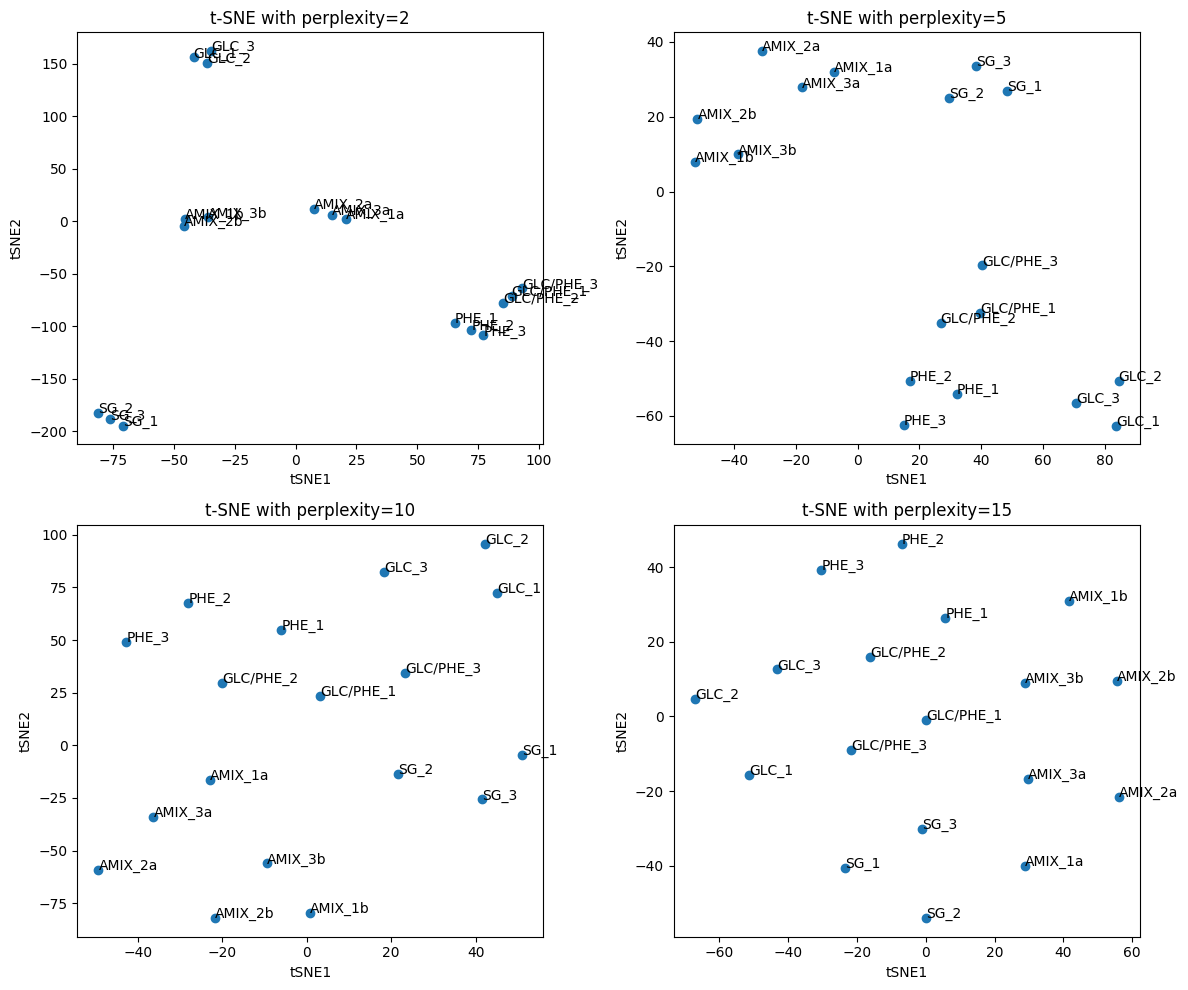

In [63]:
perplexities = [2, 5, 10, 15]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, perplexity in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    tsne_data = tsne.fit_transform(scaled_data)
    
    ax = axes[idx]
    ax.scatter(tsne_data[:, 0], tsne_data[:, 1])
    
    for i, label in enumerate(labels):
        ax.annotate(label, (tsne_data[i, 0], tsne_data[i, 1]))
    
    ax.set_title(f't-SNE with perplexity={perplexity}')
    ax.set_xlabel('tSNE1')
    ax.set_ylabel('tSNE2')

plt.tight_layout()
plt.show()